# 04. 서울시 소방 구급 출동 현황 EDA

**대상 파일:**
- `서울시 소방 구급 출동 현황(2022_2024).xlsx` — 서울 2022~2024 출동 현황 (Excel)
- `소방청_서울특별시 주소별 구급출동현황_20191231.csv` — 주소별 구급 출동 (CP949)
- `소방청_119신고 전화 유형_20231231.csv` — 연도별 신고 유형 (CP949)

**목표:** 서울 구급 출동 트렌드 및 유형 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('../data')
print('데이터 디렉토리:', DATA_DIR.resolve())

데이터 디렉토리: D:\DMU\빅데이터분석프로젝트\BigdataAnalysis-project\data


## 1. Excel 데이터 로드 — 서울시 소방 구급 출동 현황(2022~2024)

In [2]:
excel_path = DATA_DIR / '서울시 소방 구급 출동 현황(2022_2024).xlsx'

# 시트 목록 확인
xl = pd.ExcelFile(excel_path, engine='openpyxl')
print('시트 목록:', xl.sheet_names)

시트 목록: ['2022년', '2023년', '2024년']


In [3]:
# 각 시트 로드
sheets = {}
for sheet in xl.sheet_names:
    df_temp = pd.read_excel(excel_path, sheet_name=sheet, engine='openpyxl')
    sheets[sheet] = df_temp
    print(f'\n--- 시트: {sheet} ({df_temp.shape[0]}행 × {df_temp.shape[1]}열) ---')
    display(df_temp.head(5))


--- 시트: 2022년 (497행 × 13열) ---


,구분,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,강남구,2601.0,2667.0,3465.0,3048.0,3226.0,3163.0,3614.0,3781.0,3232.0,3093.0,3139.0,3572.0
1,개포동,196.0,299.0,302.0,245.0,276.0,229.0,259.0,290.0,252.0,210.0,213.0,255.0
2,논현동,374.0,360.0,461.0,404.0,450.0,419.0,524.0,480.0,453.0,417.0,403.0,539.0
3,대치동,276.0,274.0,332.0,326.0,361.0,370.0,413.0,404.0,354.0,346.0,322.0,389.0
4,도곡동,189.0,190.0,235.0,189.0,164.0,188.0,197.0,248.0,168.0,161.0,173.0,188.0



--- 시트: 2023년 (495행 × 13열) ---


,구분,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,강남구,3012.0,2691.0,3081.0,3259.0,3549.0,3465.0,3688.0,3569.0,3283.0,3187.0,2892.0,3274.0
1,개포동,222.0,182.0,231.0,252.0,266.0,287.0,263.0,259.0,247.0,257.0,231.0,229.0
2,논현동,405.0,383.0,435.0,467.0,456.0,472.0,530.0,518.0,443.0,415.0,402.0,442.0
3,대치동,343.0,280.0,334.0,331.0,414.0,361.0,397.0,414.0,389.0,366.0,318.0,357.0
4,도곡동,155.0,153.0,181.0,169.0,203.0,209.0,183.0,168.0,186.0,142.0,160.0,181.0



--- 시트: 2024년 (494행 × 13열) ---


,구분,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,강남구,2882.0,2621.0,2799.0,2980.0,3131.0,3167.0,3471.0,3560.0,2774.0,2670.0,2868.0,2890.0
1,강남구,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2,개포동,252.0,231.0,240.0,261.0,270.0,271.0,298.0,289.0,256.0,214.0,259.0,244.0
3,논현동,382.0,400.0,376.0,395.0,392.0,428.0,462.0,487.0,406.0,373.0,380.0,390.0
4,대치동,305.0,286.0,307.0,308.0,382.0,361.0,409.0,422.0,294.0,314.0,327.0,333.0


In [4]:
# 첫 번째 시트 상세 분석
df_excel = sheets[xl.sheet_names[0]]
print('컬럼 목록:')
for col in df_excel.columns:
    print(f'  {col}: {df_excel[col].dtype} | null: {df_excel[col].isnull().sum()}')

컬럼 목록:
  구분: object | null: 0
  1월: float64 | null: 15
  2월: float64 | null: 13
  3월: float64 | null: 13
  4월: float64 | null: 9
  5월: float64 | null: 9
  6월: float64 | null: 9
  7월: float64 | null: 9
  8월: float64 | null: 9
  9월: float64 | null: 9
  10월: float64 | null: 10
  11월: float64 | null: 12
  12월: float64 | null: 13


## 2. 119 신고 전화 유형 데이터 로드

In [5]:
df_call_type = pd.read_csv(
    DATA_DIR / '소방청_119신고 전화 유형_20231231.csv',
    encoding='euc-kr'
)
print(f'행: {df_call_type.shape[0]:,} | 열: {df_call_type.shape[1]}')
print('컬럼:', df_call_type.columns.tolist())
df_call_type.head(10)

행: 26 | 열: 12
컬럼: ['연도별', ' 유형 ', ' 화 재 ', ' 구 조 ', ' 구 급 ', ' 대민출동 및 기타 ', ' 유관기관 이첩 ', ' 안내 및 민원 ', ' 장난전화 ', ' 무응답 ', ' 오접속 ', ' 기 타  ']


,연도별,유형,화 재,구 조,구 급,대민출동 및 기타,유관기관 이첩,안내 및 민원,장난전화,무응답,오접속,기 타
0,2011,유선,61504,137825,747385,317208,48941,733607,8301,309378,2643278,1182085
1,2011,무선,160109,221549,1292905,281186,77290,1752950,11996,1628968,7783721,2401061
2,2012,유선,61905,162541,775063,218646,37245,1117417,6863,626853,1960473,1011228
3,2012,무선,160905,300521,1358292,227808,83532,1906533,11054,2117829,5434885,1782721
4,2013,유선,51847,132055,734678,271719,39297,1305252,3800,558732,1150015,510845
5,2013,무선,155010,301058,1449000,277562,88071,2205184,3398,1200070,2629413,721192
6,2014,유선,54003,131932,664883,346849,28086,1043680,1634,483034,736029,446910
7,2014,무선,187580,341507,1706341,287005,83016,2189825,1598,1118852,1363230,625634
8,2015,유선,51416,115197,636413,336634,15032,835236,845,313711,388098,298947
9,2015,무선,191944,361668,1825727,247870,61715,2278975,1422,917342,788012,749262


## 3. 서울특별시 주소별 구급출동현황 로드

In [6]:
df_addr = pd.read_csv(
    DATA_DIR / '소방청_서울특별시 주소별 구급출동현황_20191231.csv',
    encoding='euc-kr'
)
print(f'행: {df_addr.shape[0]:,} | 열: {df_addr.shape[1]}')
print('컬럼:', df_addr.columns.tolist())
df_addr.head(5)

행: 1,453 | 열: 7
컬럼: ['연도', '시도', '발생시도', '발생시', '발생동', '출동건수', '이송건수']


,연도,시도,발생시도,발생시,발생동,출동건수,이송건수
0,2019,서울특별시,강원도,고성군,토성면,1,0
1,2019,서울특별시,경기도,광명시,광명동,1,1
2,2019,서울특별시,경기도,광명시,하안동,1,0
3,2019,서울특별시,경기도,구리시,아천동,1,1
4,2019,서울특별시,경기도,김포시,풍무동,2,2


In [7]:
print('기본 통계:')
df_addr.describe()

기본 통계:


,연도,출동건수,이송건수
count,1453.000000,1453.000000,1453.000000
mean,2018.000688,1124.636614,706.346869
std,0.817761,1782.275516,1148.182731
min,2017.000000,1.000000,0.000000
25%,2017.000000,112.000000,64.000000
50%,2018.000000,318.000000,187.000000
75%,2019.000000,1518.000000,926.000000
max,2019.000000,14856.000000,9618.000000


## 4. 119 신고 유형 분석

In [8]:
# 연도 컬럼 찾기
year_col = [c for c in df_call_type.columns if '연도' in str(c) or 'year' in str(c).lower() or 'yr' in str(c).lower()]
print('연도 컬럼:', year_col)
print('\n데이터 전체 보기:')
display(df_call_type)

연도 컬럼: ['연도별']

데이터 전체 보기:


,연도별,유형,화 재,구 조,구 급,대민출동 및 기타,유관기관 이첩,안내 및 민원,장난전화,무응답,오접속,기 타
0,2011,유선,61504,137825,747385,317208,48941,733607,8301,309378,2643278,1182085
1,2011,무선,160109,221549,1292905,281186,77290,1752950,11996,1628968,7783721,2401061
2,2012,유선,61905,162541,775063,218646,37245,1117417,6863,626853,1960473,1011228
3,2012,무선,160905,300521,1358292,227808,83532,1906533,11054,2117829,5434885,1782721
4,2013,유선,51847,132055,734678,271719,39297,1305252,3800,558732,1150015,510845
5,2013,무선,155010,301058,1449000,277562,88071,2205184,3398,1200070,2629413,721192
6,2014,유선,54003,131932,664883,346849,28086,1043680,1634,483034,736029,446910
7,2014,무선,187580,341507,1706341,287005,83016,2189825,1598,1118852,1363230,625634
8,2015,유선,51416,115197,636413,336634,15032,835236,845,313711,388098,298947
9,2015,무선,191944,361668,1825727,247870,61715,2278975,1422,917342,788012,749262


수치형 컬럼: ['연도별', ' 화 재 ', ' 구 조 ', ' 구 급 ', ' 대민출동 및 기타 ', ' 유관기관 이첩 ', ' 안내 및 민원 ', ' 장난전화 ', ' 무응답 ', ' 오접속 ', ' 기 타  ']


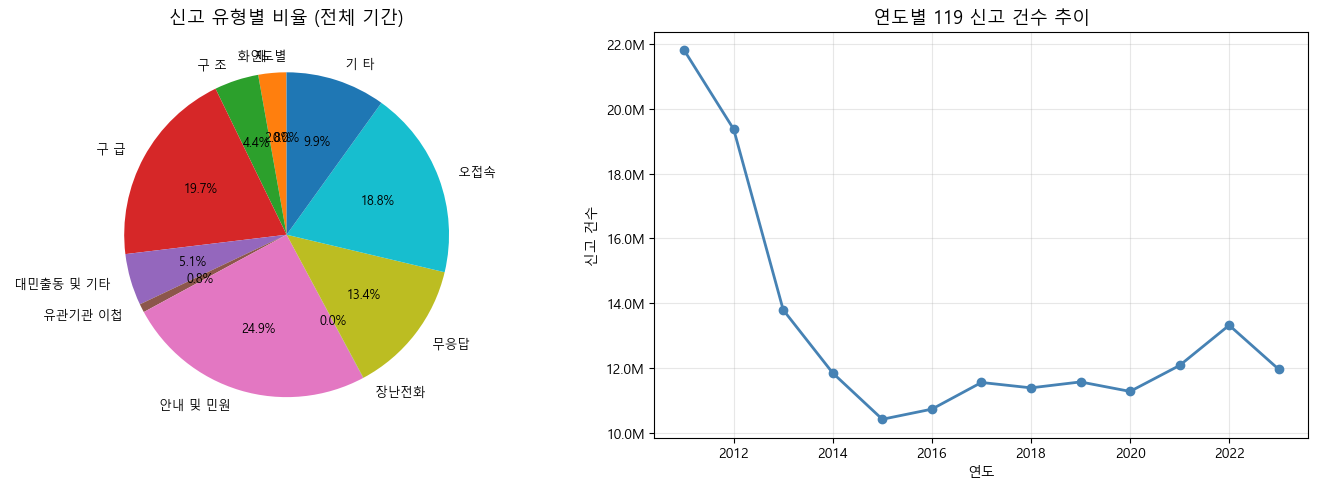

In [9]:
# 수치형 컬럼으로 시각화
numeric_cols = df_call_type.select_dtypes(include='number').columns.tolist()
print('수치형 컬럼:', numeric_cols)

if numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 전체 합계로 유형별 비율
    total_by_type = df_call_type[numeric_cols].sum()
    total_by_type = total_by_type[total_by_type > 0]
    
    axes[0].pie(total_by_type, labels=total_by_type.index, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 9})
    axes[0].set_title('신고 유형별 비율 (전체 기간)', fontsize=13)
    
    # 연도별 전체 건수 추이
    if year_col:
        df_call_type['전체합계'] = df_call_type[numeric_cols].sum(axis=1)
        yearly = df_call_type.groupby(year_col[0])['전체합계'].sum()
        axes[1].plot(yearly.index, yearly.values, marker='o', linewidth=2, color='steelblue')
        axes[1].set_title('연도별 119 신고 건수 추이', fontsize=13)
        axes[1].set_xlabel('연도')
        axes[1].set_ylabel('신고 건수')
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. 주소별 구급 출동 분석

In [10]:
# 컬럼 목록 상세 확인
print('컬럼별 데이터 타입 및 샘플값:')
for col in df_addr.columns:
    sample = df_addr[col].dropna().head(3).tolist()
    print(f'  [{col}] {df_addr[col].dtype}: {sample}')

컬럼별 데이터 타입 및 샘플값:
  [연도] int64: [2019, 2019, 2019]
  [시도] object: ['서울특별시', '서울특별시', '서울특별시']
  [발생시도] object: ['강원도', '경기도', '경기도']
  [발생시] object: ['고성군', '광명시', '광명시']
  [발생동] object: ['토성면', '광명동', '하안동']
  [출동건수] int64: [1, 1, 1]
  [이송건수] int64: [0, 1, 0]


In [11]:
# 지역 컬럼 탐색 (구/동 단위)
region_cols = [c for c in df_addr.columns
               if any(kw in str(c) for kw in ['지역', '구', '동', 'region', 'sgg', 'ctpv'])]
print('지역 컬럼 후보:', region_cols)

year_cols = [c for c in df_addr.columns
             if any(kw in str(c) for kw in ['연도', 'year', 'yr', '년'])]
print('연도 컬럼 후보:', year_cols)

numeric_addr = df_addr.select_dtypes(include='number').columns.tolist()
print('수치형 컬럼:', numeric_addr)

지역 컬럼 후보: ['발생동', '출동건수']
연도 컬럼 후보: ['연도']
수치형 컬럼: ['연도', '출동건수', '이송건수']


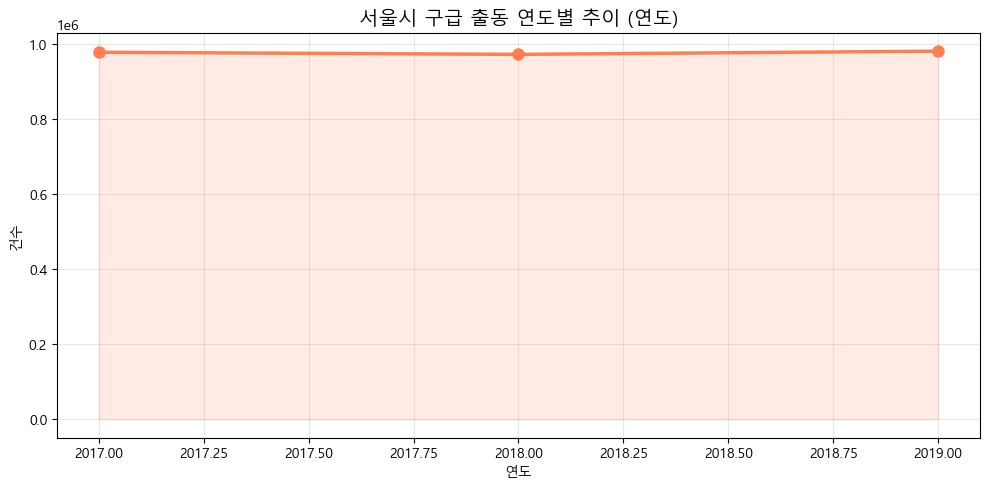

In [12]:
# 연도별 트렌드
if year_cols and numeric_addr:
    yr_col = year_cols[0]
    val_col = numeric_addr[0]  # 첫 번째 수치형 컬럼 (출동건수 등)
    
    yearly_trend = df_addr.groupby(yr_col)[val_col].sum()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly_trend.index, yearly_trend.values, marker='o', linewidth=2.5,
            markersize=8, color='coral')
    ax.fill_between(yearly_trend.index, yearly_trend.values, alpha=0.15, color='coral')
    ax.set_title(f'서울시 구급 출동 연도별 추이 ({val_col})', fontsize=14)
    ax.set_xlabel('연도')
    ax.set_ylabel('건수')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

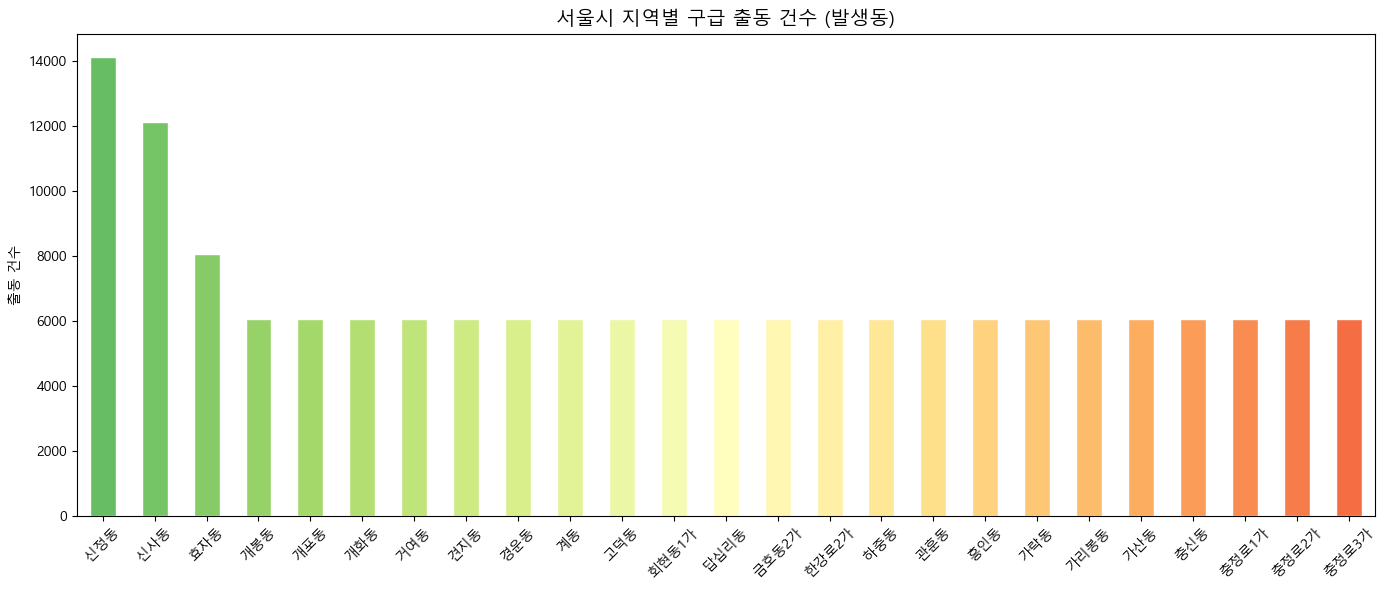

In [13]:
# 지역별 분포
if region_cols and numeric_addr:
    rg_col = region_cols[0]
    val_col = numeric_addr[0]
    
    region_total = df_addr.groupby(rg_col)[val_col].sum().sort_values(ascending=False).head(25)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(region_total)))
    region_total.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'서울시 지역별 구급 출동 건수 ({rg_col})', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('출동 건수')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 6. Excel 데이터 상세 분석

In [14]:
# Excel 수치형 컬럼 분포
excel_numeric = df_excel.select_dtypes(include='number').columns.tolist()
excel_year = [c for c in df_excel.columns if '연도' in str(c) or 'year' in str(c).lower()]

print(f'Excel 데이터: {df_excel.shape[0]}행 × {df_excel.shape[1]}열')
print('수치형 컬럼:', excel_numeric)
print('연도 컬럼:', excel_year)
display(df_excel.describe())

Excel 데이터: 497행 × 13열
수치형 컬럼: ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
연도 컬럼: []


,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
count,482.000000,484.000000,484.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,487.000000,485.000000,484.000000
mean,185.995851,189.392562,246.425620,207.049180,207.086066,198.028689,227.766393,240.327869,214.717213,207.059548,205.740206,223.603306
std,414.878591,426.460878,555.843195,467.163358,465.343852,446.436499,513.948458,543.134585,483.099636,464.521045,461.537346,502.168379
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,10.000000,9.000000,11.000000,10.000000,11.750000,11.000000,12.000000,12.750000,11.000000,11.000000,11.000000,14.000000
50%,36.000000,33.000000,42.000000,34.500000,37.000000,37.500000,42.000000,42.500000,38.500000,39.000000,40.000000,42.000000
75%,162.500000,161.750000,217.250000,184.250000,176.500000,164.250000,197.000000,214.750000,192.250000,178.500000,181.000000,197.250000
max,2601.000000,2680.000000,3554.000000,3048.000000,3226.000000,3163.000000,3614.000000,3781.000000,3232.000000,3093.000000,3139.000000,3572.000000


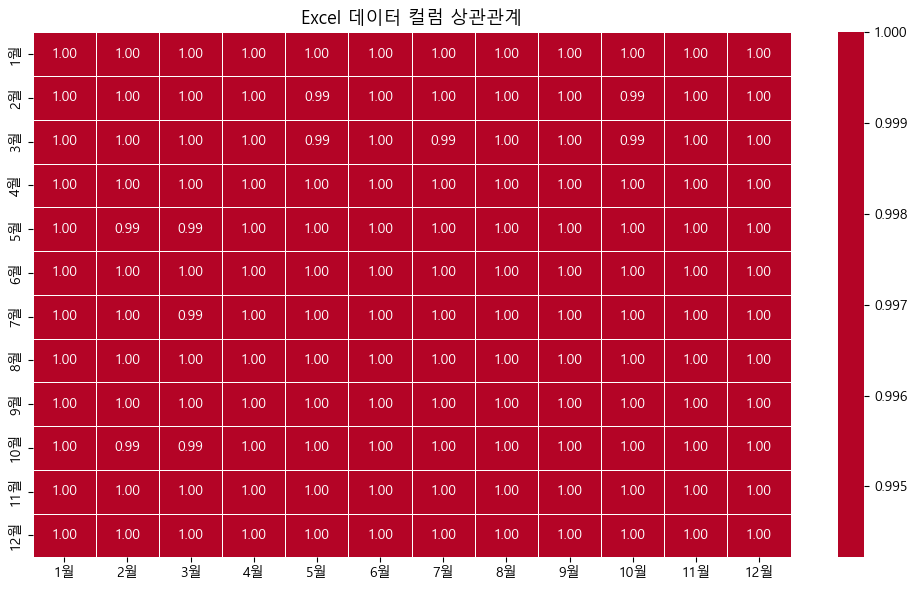

In [15]:
# 수치형 컬럼이 충분히 있으면 히트맵
if len(excel_numeric) >= 3:
    fig, ax = plt.subplots(figsize=(10, 6))
    corr = df_excel[excel_numeric].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Excel 데이터 컬럼 상관관계', fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. 요약

In [16]:
print('=== 데이터 요약 ===')
print(f'\n[Excel] 서울시 소방 구급 출동 현황(2022~2024)')
print(f'  시트 수: {len(xl.sheet_names)}개')
print(f'  총 행 수: {sum(s.shape[0] for s in sheets.values()):,}')

print(f'\n[CSV] 119 신고 전화 유형')
print(f'  행 수: {len(df_call_type):,}')
print(f'  연도 범위: {df_call_type[year_col[0]].min() if year_cols else "N/A"} ~ {df_call_type[year_col[0]].max() if year_cols else "N/A"}')

print(f'\n[CSV] 서울특별시 주소별 구급출동현황')
print(f'  행 수: {len(df_addr):,}')

=== 데이터 요약 ===

[Excel] 서울시 소방 구급 출동 현황(2022~2024)
  시트 수: 3개
  총 행 수: 1,486

[CSV] 119 신고 전화 유형
  행 수: 26
  연도 범위: 2011 ~ 2023

[CSV] 서울특별시 주소별 구급출동현황
  행 수: 1,453
